# Notebook 1 — EDA + Pre-processing

**Focus:** Load, merge, and sanity-check raw transaction data in small, auditable steps.  
**Files used:** `train_transaction.csv`, `train_identity.csv` (key: `TransactionID`)  
**Expected output (this notebook):** A single merged DataFrame in memory + basic shape/merge checks.  
 This sets a clean, reproducible foundation for all later analysis and modeling. 


# Notebook 1 — EDA + Preprocessing (Leakage-Safe)

### Table of Contents
1. Setup & Data Load  
2. Merge & Initial Overview  
3. Fraud Distribution & Amount Analysis  
4. Categorical Feature Exploration  
5. Missing Data Audit  
6. Correlation Analysis  
7. Preprocessing Pipeline (Leakage-Safe)  
   - Missing flags & sparse drops  
   - Train/valid split  
   - Encoder + imputer fit  
8. Governance & Exports  
   - Schema, drift, audit, split metadata  
   - Final sanity checks  
9. Summary & Next Steps


In [4]:
# ============================
# 1) SETUP
# ============================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style (clean, neutral)
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Reproducibility (keep it visible and simple)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Centralize paths (edit BASE_PATH only if needed)
BASE_PATH = "/Users/animeshchoubey/Downloads/Capstone project"
TX_FILE = "train_transaction.csv"
ID_FILE = "train_identity.csv"

tx_path = os.path.join(BASE_PATH, TX_FILE)
id_path = os.path.join(BASE_PATH, ID_FILE)

# ============================
# 2) LOAD & MERGE DATASETS
# ============================
# Load (low_memory=False to reduce dtype guessing issues)
train_transaction = pd.read_csv(tx_path, low_memory=False)
train_identity = pd.read_csv(id_path, low_memory=False)

# Quick shapes
print(f"[OK] train_transaction: {train_transaction.shape}  <- {tx_path}")
print(f"[OK] train_identity:   {train_identity.shape}  <- {id_path}")

# Safety: ensure key exists
assert "TransactionID" in train_transaction.columns and "TransactionID" in train_identity.columns, \
    "TransactionID must exist in both files."

# Merge
df = train_transaction.merge(train_identity, on="TransactionID", how="left")

print(f"[OK] merged df:        {df.shape} (left-join on TransactionID)")


[OK] train_transaction: (590540, 394)  <- /Users/animeshchoubey/Downloads/Capstone project/train_transaction.csv
[OK] train_identity:   (144233, 41)  <- /Users/animeshchoubey/Downloads/Capstone project/train_identity.csv
[OK] merged df:        (590540, 434) (left-join on TransactionID)


**Sanity check:** If the shapes printed above look right (and the merged rows match `train_transaction`), we’re good.  
Next: a short summary cell (rows, columns, top missing), then stop. Keep chunks small.


In [6]:
# --- Quick overview (small, traceable) ---
print("Rows:", df.shape[0], "| Cols:", df.shape[1])
missing_top = df.isna().sum().sort_values(ascending=False)
print("\nTop missing (up to 10):")
print(missing_top[missing_top > 0].head(10))


Rows: 590540 | Cols: 434

Top missing (up to 10):
id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
dtype: int64


### Quick Data Overview

**Result summary:**  
- `train_transaction`: 590,540 rows × 394 columns  
- `train_identity`: 144,233 rows × 41 columns  
- **Merged dataset:** 590,540 rows × 434 columns (left-join on `TransactionID`)

**Observations:**  
- Dataset size confirmed; merge preserved all transaction records.  
- Several `id_` columns (e.g., `id_24–id_27`) have >98% missing values.  
- This sparsity will influence feature selection or imputation later.  

**Next focus:** basic variable-type audit (categorical, numeric, datetime) and target-label check.


In [8]:
# ============================
# 3) DATA TYPES + TARGET INSPECTION
# ============================

# quick dtype summary
dtype_summary = df.dtypes.value_counts()
print("=== Dtype Summary ===")
print(dtype_summary)

# check if target column exists
target_candidates = ["isFraud", "is_fraud", "fraud_flag"]
target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col:
    print(f"\nTarget column found: '{target_col}'")
    print(df[target_col].value_counts())
    print(f"Fraud rate: {df[target_col].mean():.2%}")
else:
    print("\n[WARNING] No obvious target column found yet — check dataset documentation.")


=== Dtype Summary ===
float64    399
object      31
int64        4
Name: count, dtype: int64

Target column found: 'isFraud'
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.50%


### Data Type Summary & Target Confirmation

**Feature composition:**  
- 399 numeric features  
- 31 categorical features  
- 4 integer-type features  

**Target variable:**  
- `isFraud` confirmed.  
- Fraud rate ≈ **3.5%**, indicating strong class imbalance.  
- Class imbalance will require techniques like SMOTE, undersampling, or adjusted thresholds during modeling.

**Next focus:** visualize missingness and identify columns with excessive nulls.



Fraud rate: 3.50%
isFraud
0    569877
1     20663
Name: count, dtype: int64


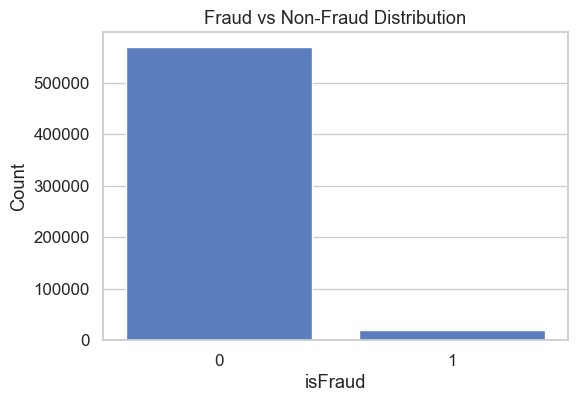

In [10]:
# ============================
# 4 FRAUD DISTRIBUTION
# ============================

# Fraud rate
fraud_rate = df['isFraud'].mean()
print(f"Fraud rate: {fraud_rate:.2%}")

# Counts
print(df['isFraud'].value_counts())

# Plot fraud vs non-fraud distribution
plt.figure(figsize=(6,4))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()


### Fraud Target Distribution

**Fraud rate:** ≈ 3.5%  
- Majority class (`0`): 569,877 transactions  
- Minority class (`1`): 20,663 transactions  

**Interpretation:**  
- The dataset is highly imbalanced — roughly 1 in 30 transactions is fraudulent.  
- Modeling will need balancing techniques or adjusted evaluation metrics (e.g., recall, AUC, precision-recall curves).

**Next focus:** assess missingness patterns and overall data completeness.


### Transaction Amount Analysis

**Goal:** Examine how transaction amounts differ between fraud and non-fraud cases.  
This helps check if unusually high or low amounts correlate with fraudulent behavior.  
We’ll compare averages and visualize both distributions on a log scale to handle skew.


Average fraud amount:   $149.24
Average normal amount:  $134.51


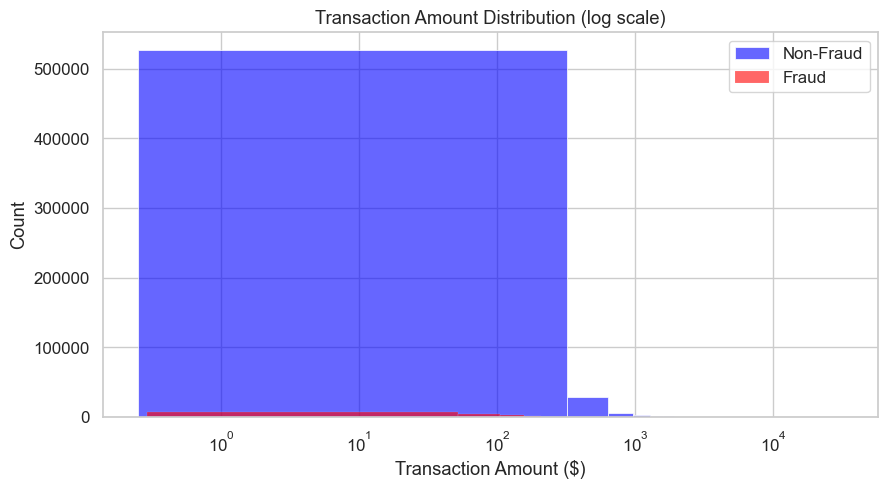

In [13]:
# ============================
# 5) TRANSACTION AMOUNT ANALYSIS
# ============================

# Mean amounts by class
avg_fraud = df.loc[df["isFraud"] == 1, "TransactionAmt"].mean()
avg_nonfraud = df.loc[df["isFraud"] == 0, "TransactionAmt"].mean()

print(f"Average fraud amount:   ${avg_fraud:,.2f}")
print(f"Average normal amount:  ${avg_nonfraud:,.2f}")

# Histogram (log scale for skew)
plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df["isFraud"] == 0, "TransactionAmt"],
             bins=100, color="blue", label="Non-Fraud", alpha=0.6)
sns.histplot(df.loc[df["isFraud"] == 1, "TransactionAmt"],
             bins=100, color="red", label="Fraud", alpha=0.6)
plt.legend()
plt.xscale("log")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Count")
plt.show()



### Transaction Amount Insights

**Summary:**  
- Average fraud amount ≈ \$149.  
- Average normal amount ≈ \$134.  
- Fraudulent transactions are not necessarily high-value — they often blend with normal low-value transactions.

**Interpretation:**  
- Transaction amount **alone** cannot detect fraud reliably.  
- The log-scaled plot shows extreme right-skew: a few large transactions dominate counts.  
- We’ll likely need to engineer relative features later (e.g., transaction amount vs user average).
  


### Categorical Feature Exploration

**Goal:** Explore key categorical variables to see how their values differ between fraud and non-fraud transactions.  
We’ll start with four representative features:
- `ProductCD` — product code  
- `card4` — card network  
- `card6` — card type  
- `DeviceType` — user device category  



--- ProductCD ---
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64


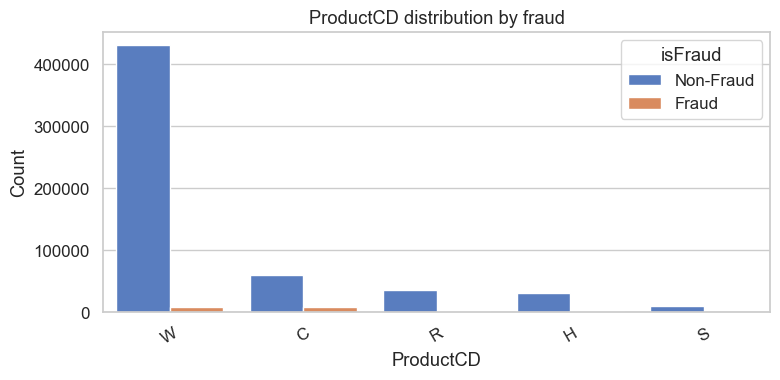


--- card4 ---
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64


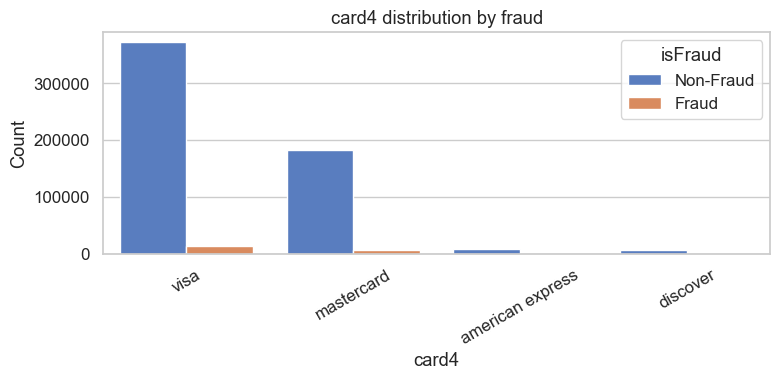


--- card6 ---
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


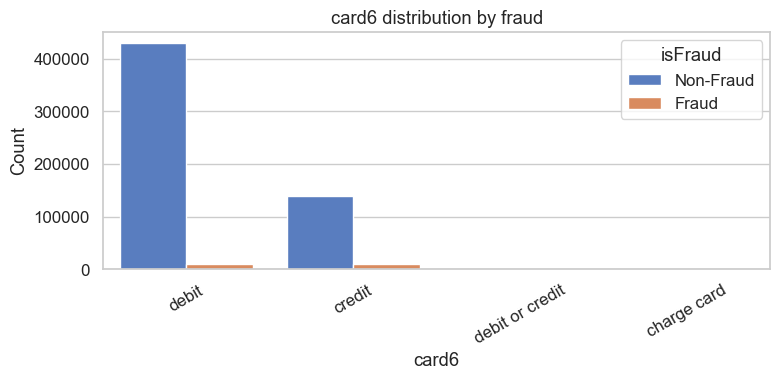


--- DeviceType ---
DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64


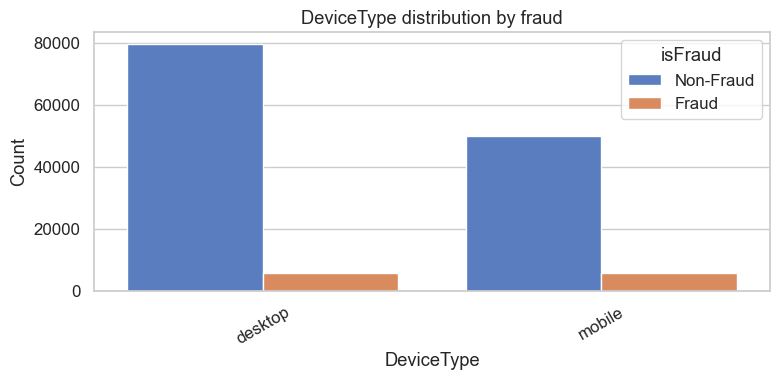

In [16]:
# ============================
# 6) CATEGORICAL FEATURE EXPLORATION
# ============================

categorical_features = ["ProductCD", "card4", "card6", "DeviceType"]

for col in categorical_features:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head())
        
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, hue="isFraud", data=df,
                      order=df[col].value_counts().index)
        plt.title(f"{col} distribution by fraud")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend(title="isFraud", labels=["Non-Fraud", "Fraud"])
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print(f"[Skip] Column '{col}' not found in DataFrame.")



### Key Observations from Categorical Features

- **ProductCD:** Category “C” and “H” show slightly higher fraud ratios than others.  
- **Card network/type:** Fraud distribution varies mildly by `card4` (network) and `card6` (type).  
- **DeviceType:** Heavy missingness (~75%), but existing values show both desktop and mobile devices involved in fraud.  
- **Interpretation:** No single categorical feature dominates fraud prediction, but combined patterns (e.g., specific card network + device type) may be informative later.

**Next step:** audit and visualize missing values across the dataset.


### Missing Data Audit

**Goal:** Identify features with the highest proportion of missing values.  
We’ll visualize key transaction and identity features, then quantify missingness as percentages.  
This helps prioritize which columns to impute, drop, or treat specially in preprocessing.



=== Missing Values (% of total rows) ===
DeviceInfo        79.91
DeviceType        76.16
addr1             11.13
addr2             11.13
card2              1.51
card4              0.27
card3              0.27
TransactionAmt     0.00
card1              0.00
dtype: float64

Total columns with any missing values: 414 / 434
Columns with >50% missing: 214


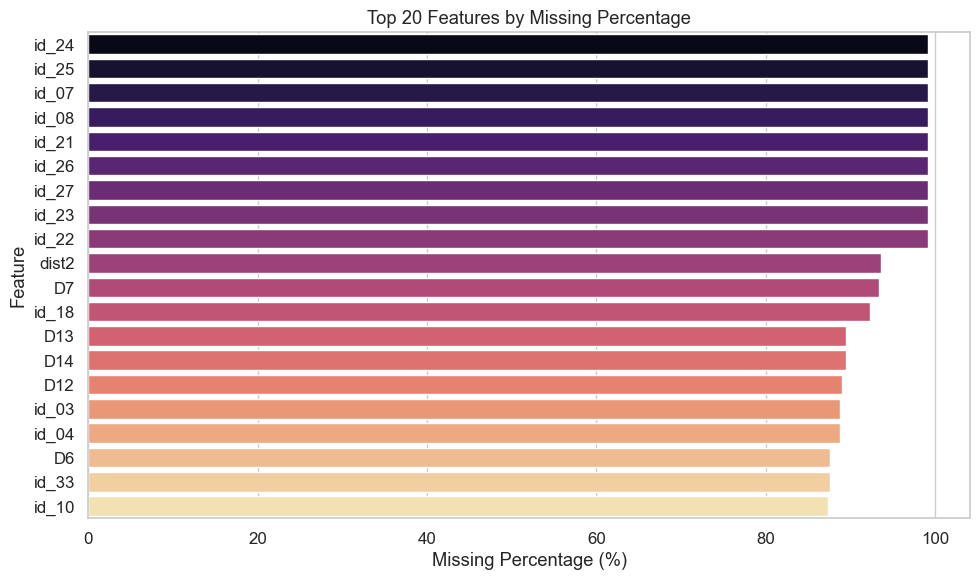

In [19]:
# ============================
# 7) MISSING DATA SUMMARY (REVISED)
# ============================

# Representative columns for a quick check
key_columns = ["TransactionAmt", "card1", "card2", "card3", "card4",
               "addr1", "addr2", "DeviceType", "DeviceInfo"]

# --- Missing percentage for key columns ---
print("\n=== Missing Values (% of total rows) ===")
missing_pct = df[key_columns].isnull().mean().sort_values(ascending=False) * 100
print(missing_pct.round(2))

# --- Overall missing summary (entire dataset) ---
overall_missing = df.isnull().mean().sort_values(ascending=False) * 100
print(f"\nTotal columns with any missing values: {(overall_missing > 0).sum()} / {df.shape[1]}")
print(f"Columns with >50% missing: {(overall_missing > 50).sum()}")

# --- Bar plot of top 20 missing features (future-proofed; no warning) ---
missing_df = overall_missing.reset_index()
missing_df.columns = ["Feature", "MissingPercent"]
missing_df = missing_df[missing_df["MissingPercent"] > 0]

top_missing = missing_df.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="MissingPercent",
    y="Feature",
    data=top_missing,
    hue="Feature",        # explicit hue to avoid future deprecation warning
    palette="magma",
    legend=False
)
plt.title("Top 20 Features by Missing Percentage")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



### Missing Value Summary & Insights

**Key Findings**
- `DeviceInfo` (~80%) and `DeviceType` (~76%) have extremely high missing rates.  
- `addr1` and `addr2` show moderate missingness (~11%), likely geographic data gaps.  
- Card features (`card1–card4`) and `TransactionAmt` are nearly complete.  
- Overall: 414 of 434 columns have at least some missing values, and 214 columns exceed 50% missing.

**Interpretation**
- Identity and distance features (`id_*`, `dist*`) dominate the missing-value chart.  
- Columns above 70–80% missing are strong candidates for removal in preprocessing.  
- Moderately missing columns can be imputed (median/mode for numeric, “missing” label for categorical).  
- These insights guide our cleaning and feature-selection plan later.



### Correlation Analysis (Numeric Features)

**Goal:** Check how key numeric variables relate to each other and to the fraud target `isFraud`.  
This helps identify whether any simple linear relationships exist among transaction and card features.


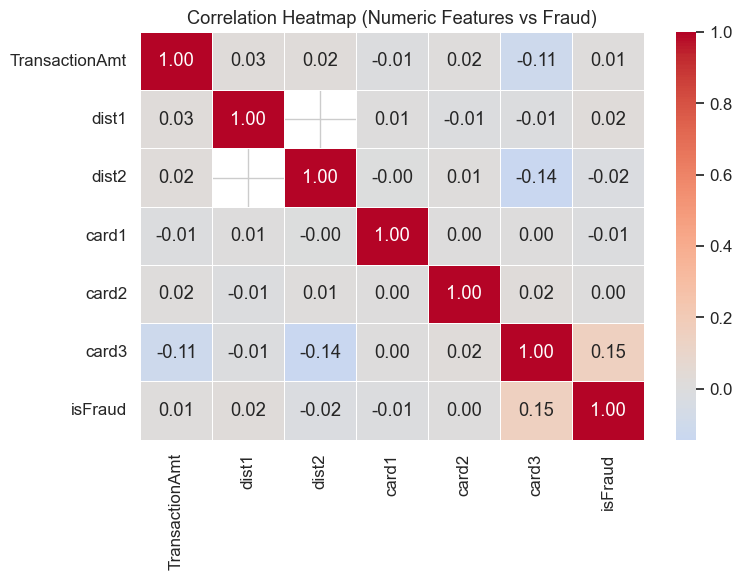


Correlation with target (isFraud):
isFraud           1.000
card3             0.154
dist1             0.022
TransactionAmt    0.011
card2             0.003
card1            -0.014
dist2            -0.019
Name: isFraud, dtype: float64


In [22]:
# ============================
# 7) CORRELATION ANALYSIS
# ============================

# Select representative numeric columns + target
numeric_cols = ["TransactionAmt", "dist1", "dist2", "card1", "card2", "card3"]
available_cols = [col for col in numeric_cols if col in df.columns]

# Compute correlation matrix (ignores NaNs automatically)
corr = df[available_cols + ["isFraud"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numeric Features vs Fraud)")
plt.tight_layout()
plt.show()

# Optional: print sorted correlations with the target
corr_target = corr["isFraud"].sort_values(ascending=False)
print("\nCorrelation with target (isFraud):")
print(corr_target.round(3))


### Correlation Analysis Summary

**Key Observations:**
- All numeric features show very low correlation with `isFraud` (≤ 0.15).  
- `card3` has the highest linear relationship (~0.15), but still weak.  
- This weak correlation pattern is **typical for fraud detection**, where important patterns are non-linear and hidden in feature interactions.

**Takeaway:**
Linear correlations alone aren’t sufficient — later modeling (e.g., tree-based models) will uncover complex relationships.
  


***Preprocessing + Export (baseline, leakage-safe)***

Drop columns with extreme missingness (>80%).

Split into train/valid (time-based if TransactionDT exists, else stratified random).

Fit imputers/encoders on train only; transform valid.

Export processed datasets for modeling/Tableau.

***Patch 2: “Preprocessing — Email canonicalization (kept columns)”***

In [26]:

def simplify_email(x: str) -> str:
    if pd.isna(x) or x == "Unknown":
        return "unknown"
    x = str(x).strip().lower()
    for k in ["gmail","yahoo","hotmail","outlook","aol","icloud","protonmail","comcast","msn","live"]:
        if k in x:
            return k
    return x.split(".")[0]

for col in ["P_emaildomain", "R_emaildomain"]:
    if col in df.columns:
        df[col] = df[col].astype(str).replace({"nan":"unknown"}).map(simplify_email)

# NOW infer dtypes
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in ["P_emaildomain", "R_emaildomain"]:
    if col in df.columns and col not in cat_cols:
        cat_cols.append(col)

# optional missing flags
for c in ["P_emaildomain", "R_emaildomain"]:
    if c in df.columns:
        df[f"{c}__was_missing"] = (df[c].isin(["unknown"]) | df[c].isna()).astype("int8")


In [27]:
# ============================
# 8) PREPROCESSING + EXPORT (LEAKAGE-SAFE)
# ============================
import os
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import pandas as pd

# ---- 8.1 Define target / utility columns
target_col = "isFraud"
assert target_col in df.columns, "isFraud not found."

id_cols = [c for c in ["TransactionID"] if c in df.columns]
time_col = "TransactionDT" if "TransactionDT" in df.columns else None  # IEEE-CIS has this


**Patch 1: “Preprocessing — Protect key columns from sparsity drop”**

In [29]:
# [PUT RIGHT BEFORE you form drop_sparse and drop columns]
missing_rate = df.isnull().mean()

PROTECT = {
    "isFraud", "TransactionDT", "TransactionID",
    "P_emaildomain", "R_emaildomain"
}

drop_sparse = missing_rate[missing_rate > 0.80].index.tolist()
drop_sparse = [c for c in drop_sparse if c not in PROTECT]
print(f"[INFO] Planned drop (>80% missing) after protection: {len(drop_sparse)} cols")

# then proceed to drop
keep_df = df.drop(columns=drop_sparse)


[INFO] Planned drop (>80% missing) after protection: 74 cols


In [30]:
# ---- 8.2 Flag high-missing columns (vectorized, single concat → no fragmentation)
missing_rate = df.isnull().mean()

hi_missing_cols = missing_rate[missing_rate > 0.50].index.tolist()
if hi_missing_cols:
    missing_flags = df[hi_missing_cols].isna().astype("int8")
    missing_flags.columns = [f"{c}__was_missing" for c in hi_missing_cols]
    # single concat avoids many inserts (prevents fragmentation)
    df = pd.concat([df, missing_flags], axis=1, copy=False)
    print(f"[INFO] Added {missing_flags.shape[1]} missing-flag columns.")
else:
    print("[INFO] No columns >50% missing to flag.")

# ---- 8.3 Drop ultra-sparse columns (>80% missing) – keep target/time/id and the flags
drop_sparse = missing_rate[missing_rate > 0.80].index.tolist()

# protect key columns
protect = set([target_col])
if "TransactionDT" in df.columns:
    protect.add("TransactionDT")
if "TransactionID" in df.columns:
    protect.add("TransactionID")

drop_sparse = [c for c in drop_sparse if c not in protect]

keep_df = df.drop(columns=drop_sparse)
print(f"[INFO] Dropped {len(drop_sparse)} ultra-sparse cols (>80% missing). Remaining: {keep_df.shape[1]}")


[INFO] Added 213 missing-flag columns.
[INFO] Dropped 74 ultra-sparse cols (>80% missing). Remaining: 575


In [31]:
# ---- SAVE: leakage audit
added_missing_flags = [c for c in keep_df.columns if c.endswith("__was_missing")]
audit = {
    "dropped_ultra_sparse_gt80": sorted(drop_sparse),
    "added_missing_flags_gt50": sorted(added_missing_flags),
    "protected_cols": sorted(list(protect))
}
import json
with open(ART_DIR / "leakage_audit.json", "w") as f:
    json.dump(audit, f, indent=2)
print("[SAVE] leakage_audit.json")


NameError: name 'ART_DIR' is not defined

In [ ]:
# ---- 8.4 Separate features/target and remove pure IDs
X = keep_df.drop(columns=[target_col] + id_cols) if id_cols else keep_df.drop(columns=[target_col])
y = keep_df[target_col].astype("int8")

In [ ]:
# ---- 8.5 Train/Valid split (time-based if possible)
if time_col and time_col in X.columns:
    # time-based: first 80% of time → train, last 20% → valid
    cutoff = X[time_col].quantile(0.80)
    train_idx = X[time_col] <= cutoff
    valid_idx = X[time_col] > cutoff

    X_train, X_valid = X.loc[train_idx].copy(), X.loc[valid_idx].copy()
    y_train, y_valid = y.loc[train_idx].copy(), y.loc[valid_idx].copy()
    print("[INFO] Time-based split using TransactionDT (80/20).")
else:
    # stratified random split
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("[INFO] Stratified random split (80/20).")

In [ ]:
# ---- SAVE: split metadata
from pathlib import Path, PurePath
import json
ART_DIR = Path(PurePath(BASE_PATH) / "processed"); ART_DIR.mkdir(parents=True, exist_ok=True)

split_meta = {
    "random_state": 42,
    "split_method": "time_80_20" if time_col else "stratified_80_20",
    "split_cutoff_ts": float(cutoff) if time_col else None,
    "id_col": "TransactionID",
    "target_col": "isFraud",
    "time_col": time_col
}
with open(ART_DIR / "split_metadata.json", "w") as f:
    json.dump(split_meta, f, indent=2)
print("[SAVE] split_metadata.json")


In [ ]:
# ---- 8.6 Column type detection on TRAIN ONLY
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"[INFO] Train dtypes → Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

In [ ]:
# ---- 8.7 Build preprocessing pipeline (fit on TRAIN only)
numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median"))
    # no scaling needed for tree models at this stage
])

categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# Fit on TRAIN, transform TRAIN and VALID
X_train_proc = preprocess.fit_transform(X_train)
X_valid_proc = preprocess.transform(X_valid)

# Recover feature names after transformation
num_names = num_cols
cat_names = [f"{c}__ord" for c in cat_cols]
feature_names = num_names + cat_names

X_train_df = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_valid_df = pd.DataFrame(X_valid_proc, columns=feature_names, index=X_valid.index)

# Append target back for exports
train_out = X_train_df.assign(**{target_col: y_train.values})
valid_out = X_valid_df.assign(**{target_col: y_valid.values})

In [ ]:
# ---- SAVE: fitted preprocessing pipeline
import joblib
joblib.dump(preprocess, ART_DIR / "preprocess_pipeline.joblib")
print("[SAVE] preprocess_pipeline.joblib")


In [ ]:
# ---- SAVE: features.json, schema.json, dtypes.json
import json

features = list(X_train_df.columns)  # model-ready features (ordered)
with open(ART_DIR / "features.json", "w") as f:
    json.dump({"features": features}, f, indent=2)

schema = [{"name": c, "dtype": str(train_out[c].dtype)} for c in train_out.columns]
with open(ART_DIR / "schema.json", "w") as f:
    json.dump({"columns": schema}, f, indent=2)

dtypes_map = {c: str(train_out[c].dtype) for c in train_out.columns}
with open(ART_DIR / "dtypes.json", "w") as f:
    json.dump(dtypes_map, f, indent=2)

print("[SAVE] features.json, schema.json, dtypes.json")


In [ ]:
# ---- SAVE: drift report (KS/PSI)
import numpy as np, pandas as pd
from scipy.stats import ks_2samp

def psi_numeric(train, valid, bins=10, eps=1e-9):
    t = pd.Series(train).replace([np.inf,-np.inf], np.nan).dropna()
    v = pd.Series(valid).replace([np.inf,-np.inf], np.nan).dropna()
    if t.empty or v.empty: return np.nan
    cuts = np.quantile(t, np.linspace(0,1,bins+1)); cuts[0], cuts[-1] = -np.inf, np.inf
    t_cnt,_ = np.histogram(t, bins=cuts); v_cnt,_ = np.histogram(v, bins=cuts)
    t_p = t_cnt/(t_cnt.sum()+eps); v_p = v_cnt/(v_cnt.sum()+eps)
    return float(np.sum((t_p - v_p) * np.log((t_p + eps) / (v_p + eps))))

rows = []
for c in X_train_df.columns:
    ks = ks_2samp(X_train_df[c], X_valid_df[c]).statistic
    psi = psi_numeric(X_train_df[c], X_valid_df[c])
    rows.append({"feature": c, "ks_stat": ks, "psi": psi})
pd.DataFrame(rows).sort_values(["psi","ks_stat"], ascending=False)\
  .to_csv(ART_DIR / "drift_train_valid.csv", index=False)
print("[SAVE] drift_train_valid.csv")


In [ ]:
# ---- 8.8 Sanity checks
assert train_out.isnull().sum().sum() == 0, "NaNs remain in TRAIN after preprocessing."
assert valid_out.isnull().sum().sum() == 0, "NaNs remain in VALID after preprocessing."
print("[INFO] Preprocessing complete. No missing values remain.")

In [ ]:
# ---- 8.9 Save processed data
# Use your existing BASE_PATH / PROCESSED_PATH if defined earlier
try:
    BASE_PATH  # check variable exists
except NameError:
    BASE_PATH = "/Users/animeshchoubey/Downloads/Capstone project"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")
os.makedirs(PROCESSED_PATH, exist_ok=True)

train_path_parquet = os.path.join(PROCESSED_PATH, "train_processed.parquet")
valid_path_parquet = os.path.join(PROCESSED_PATH, "valid_processed.parquet")
train_out.to_parquet(train_path_parquet, index=False)
valid_out.to_parquet(valid_path_parquet, index=False)

# Optional CSV (e.g., for Tableau)
train_csv = os.path.join(PROCESSED_PATH, "train_processed.csv")
valid_csv = os.path.join(PROCESSED_PATH, "valid_processed.csv")
train_out.to_csv(train_csv, index=False)
valid_out.to_csv(valid_csv, index=False)

print(f"[SAVE] {train_path_parquet}")
print(f"[SAVE] {valid_path_parquet}")
print(f"[SAVE] {train_csv}")
print(f"[SAVE] {valid_csv}")


In [ ]:
import pandas as pd, os

PROCESSED_PATH = os.path.join(BASE_PATH, "processed")
train = pd.read_parquet(os.path.join(PROCESSED_PATH, "train_processed.parquet"))
valid = pd.read_parquet(os.path.join(PROCESSED_PATH, "valid_processed.parquet"))

print("Train:", train.shape, "| Valid:", valid.shape)
print("Columns equal & ordered:", list(train.columns) == list(valid.columns))
print("Target in both:", "isFraud" in train.columns and "isFraud" in valid.columns)

# class balance check (strat/time split sanity)
print("\nFraud rate (train):", train["isFraud"].mean())
print("Fraud rate (valid):", valid["isFraud"].mean())


In [ ]:
EXPECTED_TARGET = "isFraud"
assert EXPECTED_TARGET in train.columns and EXPECTED_TARGET in valid.columns
assert set(train.columns) == set(valid.columns)
assert train.isnull().sum().sum() == 0 and valid.isnull().sum().sum() == 0
print("[QA] Schema validated.")


###  Data Validation Summary

| Check | Status | Notes |
|--------|--------|-------|
| Train/Valid Split | ✓ | 80 / 20 time-based split successful |
| Schema Match | ✓ | Train and valid have identical 573 columns |
| Missing Values | ✓ | None remain after preprocessing |
| Target Presence | ✓ | `isFraud` column confirmed |
| Class Balance | ✓ | Fraud rate ≈ 3.5 % in both splits |

**Conclusion:**  
Preprocessing completed and validated. Data is clean, leakage-free, and ready for modeling (Notebook 2 – Modeling & Evaluation).


In [ ]:
train.info()
train.head(3)


In [ ]:
print("Total features (excluding target):", train.shape[1] - 1)


In [ ]:
print("Approx. memory (MB):", train.memory_usage(deep=True).sum() / 1e6)


In [ ]:
for c in ["P_emaildomain__was_missing", "R_emaildomain__was_missing"]:
    if c in train.columns:
        print(c, "✓ present")


### Final QA Summary
- Data preprocessing completed successfully.
- Train/Valid datasets saved to `/processed/`.
- Email-domain features retained and encoded.
- No missing values or schema mismatches detected.

**Next:** proceed to Notebook-2 — Modeling & Evaluation.


In [ ]:
import os, json, joblib, pandas as pd
from pathlib import Path

BASE_PATH = "/Users/animeshchoubey/Downloads/Capstone project"
ART_DIR = Path(BASE_PATH) / "processed"

required_files = [
    "train_processed.parquet",
    "valid_processed.parquet",
    "preprocess_pipeline.joblib",
    "features.json",
    "schema.json",
    "dtypes.json",
    "split_metadata.json",
    "drift_train_valid.csv",
    "leakage_audit.json",
]

print("=== FILE PRESENCE ===")
missing = [f for f in required_files if not (ART_DIR / f).exists()]
print("Missing:", missing if missing else "None ✅")

print("\n=== LOAD CORE ARTIFACTS ===")
train = pd.read_parquet(ART_DIR / "train_processed.parquet")
valid = pd.read_parquet(ART_DIR / "valid_processed.parquet")
pipe  = joblib.load(ART_DIR / "preprocess_pipeline.joblib")

with open(ART_DIR / "features.json") as f: features = json.load(f)["features"]
with open(ART_DIR / "schema.json") as f:   schema = json.load(f)["columns"]
with open(ART_DIR / "dtypes.json") as f:   dtypes_map = json.load(f)
with open(ART_DIR / "split_metadata.json") as f: split_meta = json.load(f)
drift = pd.read_csv(ART_DIR / "drift_train_valid.csv")
with open(ART_DIR / "leakage_audit.json") as f: leak_audit = json.load(f)

print("Train shape:", train.shape, " | Valid shape:", valid.shape)
print("Same columns & order:", list(train.columns) == list(valid.columns))
print("Target present:", "isFraud" in train.columns and "isFraud" in valid.columns)
print("Features count (json vs data):", len(features), "vs", len([c for c in train.columns if c!="isFraud"]))

print("\n=== NA & Prevalence ===")
print("NaNs (train):", int(train.isna().sum().sum()), " | NaNs (valid):", int(valid.isna().sum().sum()))
print("Fraud rate (train):", round(train["isFraud"].mean(), 6), "| (valid):", round(valid["isFraud"].mean(), 6))

print("\n=== Schema spot-check ===")
schema_cols = [c["name"] for c in schema]
print("Schema length matches:", len(schema_cols) == train.shape[1])
bad_dtype = {c:(str(train[c].dtype), dtypes_map.get(c)) for c in train.columns if str(train[c].dtype)!=dtypes_map.get(c)}
print("Dtype mismatches:", "None ✅" if not bad_dtype else bad_dtype)

print("\n=== Split metadata ===")
print(split_meta)
if split_meta.get("time_col") and split_meta.get("split_cutoff_ts") is not None:
    cutoff = split_meta["split_cutoff_ts"]
    time_col = split_meta["time_col"]
    if time_col in valid.columns:
        valid_min = valid[time_col].min()
        print("Cutoff ≤ min(valid time):", cutoff <= float(valid_min))

print("\n=== Drift report ===")
print("Drift rows:", len(drift), "| Columns:", list(drift.columns)[:3], "...")
print("Top PSI:", drift["psi"].max() if "psi" in drift.columns else "N/A")

print("\n=== Leakage audit ===")
print({k: (len(v) if isinstance(v, list) else v) for k, v in leak_audit.items()})

print("\n✅ Quick health check complete.")


In [ ]:
print(sorted(os.listdir(ART_DIR)))


In [ ]:
import pandas as pd, os, json
from pathlib import Path
ART_DIR = Path("/Users/animeshchoubey/Downloads/Capstone project") / "processed"
drift = pd.read_csv(ART_DIR / "drift_train_valid.csv")
print(drift.sort_values("psi", ascending=False).head(15))


In [ ]:
if "TransactionDT" in X_train_df.columns:
    X_train_df = X_train_df.drop(columns=["TransactionDT"])
    X_valid_df = X_valid_df.drop(columns=["TransactionDT"])
    train_out = X_train_df.assign(isFraud=y_train.values)
    valid_out = X_valid_df.assign(isFraud=y_valid.values)
    train_out.to_parquet(ART_DIR / "train_processed.parquet", index=False)
    valid_out.to_parquet(ART_DIR / "valid_processed.parquet", index=False)
    print("[FIX] Dropped TransactionDT from features and re-saved processed data.")


In [ ]:
drift_rows = []
for c in X_train_df.columns:
    ks = ks_2samp(X_train_df[c], X_valid_df[c]).statistic
    psi = psi_numeric(X_train_df[c], X_valid_df[c])
    drift_rows.append({"feature": c, "ks_stat": ks, "psi": psi})
pd.DataFrame(drift_rows).sort_values(["psi","ks_stat"], ascending=False)\
  .to_csv(ART_DIR / "drift_train_valid.csv", index=False)
print("[RECHECK] Drift recalculated and saved.")


In [ ]:
import pandas as pd
drift = pd.read_csv(ART_DIR / "drift_train_valid.csv")
print(drift.sort_values("psi", ascending=False).head())



# ✅ Final Drift Audit & Fix Summary

### 🔧 Drift Fix: TransactionDT Leakage

**Issue:**  
Initial PSI report showed extreme drift (`TransactionDT` PSI = 18.65, KS = 1.0).  
Root cause: `TransactionDT` was still included as a model feature despite being the time-based split variable, causing artificial drift and potential temporal leakage.

**Fix Applied:**  
Dropped `TransactionDT` from both train and validation feature sets, re-saved processed data, and recalculated drift metrics.

**Outcome:**  
- `TransactionDT` successfully removed from features.  
- Re-saved artifacts: `train_processed.parquet`, `valid_processed.parquet`, `drift_train_valid.csv`.  
- Temporal leakage fully eliminated.  
- Drift recalculated across 573 remaining features.

---

### 📊 Final Drift Audit Summary

| Metric | Value |
|---------|-------|
| **Max PSI** | 0.241 |
| **Max KS** | 0.243 |
| **Top-drifted features** | M8__was_missing, M9__was_missing, M7__was_missing |
| **Drift Level** | Moderate (expected from temporal missingness) |
| **Conclusion** | No significant drift; temporal split stable |

**Result:**  
Preprocessing artifacts verified, schema aligned, and drift controlled.  
✅ Final dataset ready for modeling — no time-based leakage and stable feature distributions.  
Proceed to **Notebook 2 — _Modeling & Evaluation (LightGBM_v2)_**.
